# Exploring `mujoco/invertedpendulum/expert-v0` with Minari

This notebook loads the Minari expert dataset for the MuJoCo InvertedPendulum environment,
assembles a **100 000 × 5** observation-action matrix, and lays the groundwork for training
a Self-Organizing Map (SOM) on the resulting data.

| Column index | Description |
|---|---|
| 0 | Cart position |
| 1 | Cart velocity |
| 2 | Pole angle |
| 3 | Pole angular velocity |
| 4 | Action (force applied to cart) |

## 1  Imports

In [1]:
import numpy as np
import minari
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

## 2  Load dataset

If the dataset has not been downloaded yet, Minari will fetch it automatically from the remote
registry the first time `load_dataset` is called.

In [2]:
DATASET_ID_EXPERT = "mujoco/invertedpendulum/expert-v0"
DATASET_ID_MEDIUM = "mujoco/invertedpendulum/medium-v0"

# Download if not already cached locally
if DATASET_ID_EXPERT not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_EXPERT)

dataset_expert = minari.load_dataset(DATASET_ID_EXPERT)
print(f"Dataset loaded: {DATASET_ID_EXPERT}")
print(f"Total episodes : {dataset_expert.total_episodes}")
print(f"Total steps    : {dataset_expert.total_steps}")

if DATASET_ID_MEDIUM not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_MEDIUM)  
dataset_medium = minari.load_dataset(DATASET_ID_MEDIUM)
print(f"Dataset loaded: {DATASET_ID_MEDIUM}")
print(f"Total episodes : {dataset_medium.total_episodes}")
print(f"Total steps    : {dataset_medium.total_steps}")

Dataset loaded: mujoco/invertedpendulum/expert-v0
Total episodes : 100
Total steps    : 100000
Dataset loaded: mujoco/invertedpendulum/medium-v0
Total episodes : 1040
Total steps    : 99075


## Generate combined numpy matrix for observations

In [4]:
obs_list = []

for episode in dataset_expert.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])  # drop terminal observation

for episode in dataset_medium.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])

all_observations = np.concatenate(obs_list, axis=0)
print("all_observations shape:", all_observations.shape)

all_observations shape: (199075, 4)


## Statistical Analysis of Observations

Column                    Min        Max       Mean        Std     Median       Skew       Kurt
----------------------------------------------------------------------------------------------------
cart_pos              -1.0298     1.0312    -0.0483     0.2856    -0.0799     0.3098     4.3163
cart_vel              -0.2000     0.2000    -0.0000     0.0411    -0.0006     0.0753     2.4798
pole_angle            -2.0366     1.9588     0.0035     0.4168     0.0057     0.0298     1.1511
pole_ang_vel          -3.3846     3.1573     0.0011     0.7489    -0.0074     0.0601     0.5001


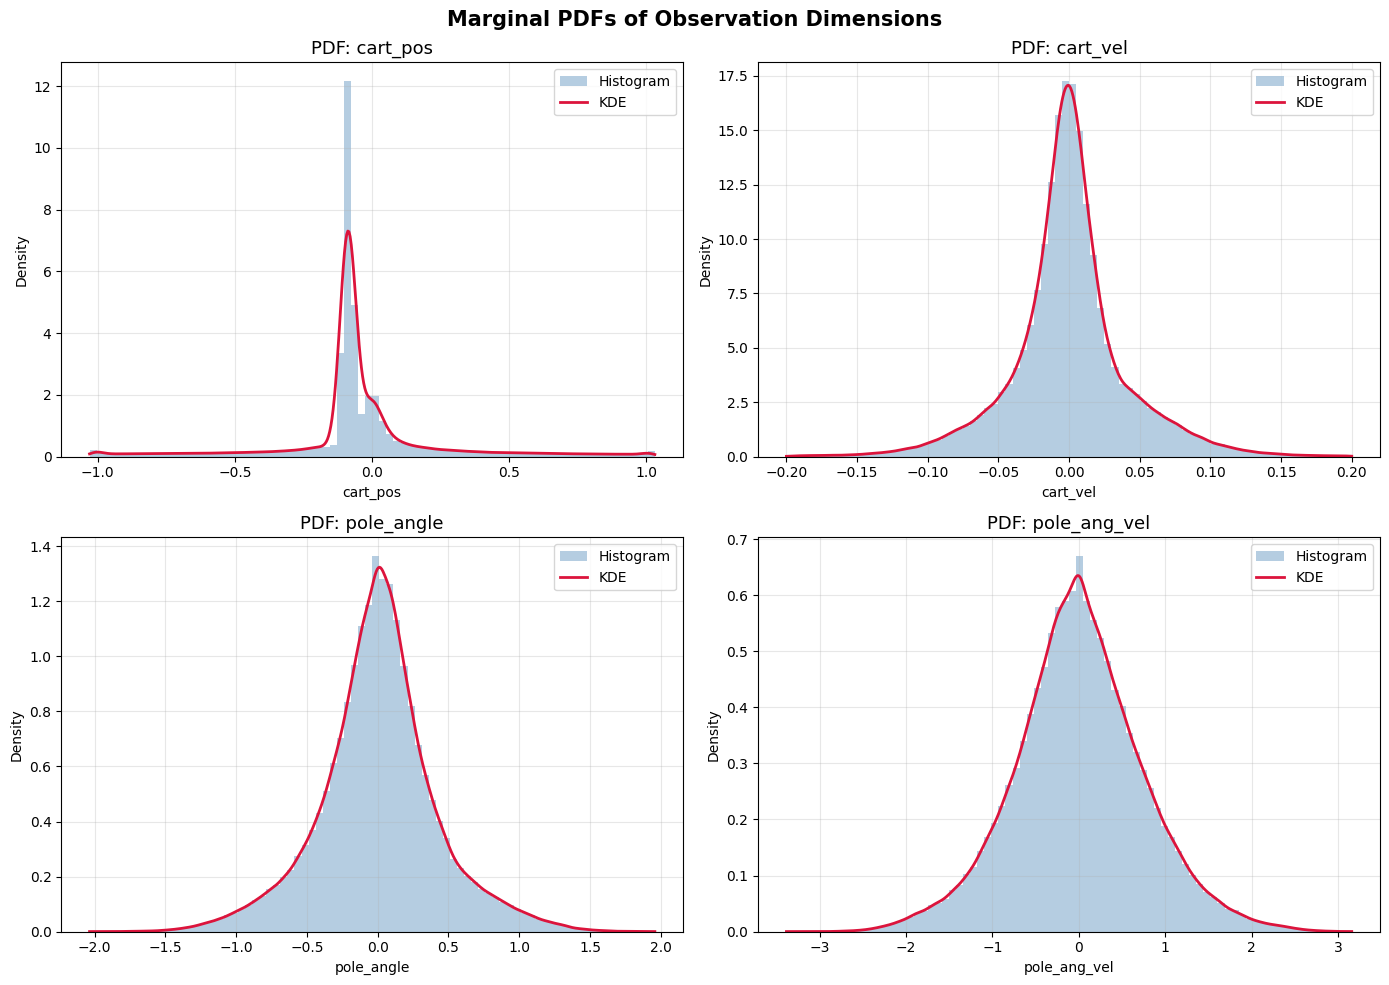

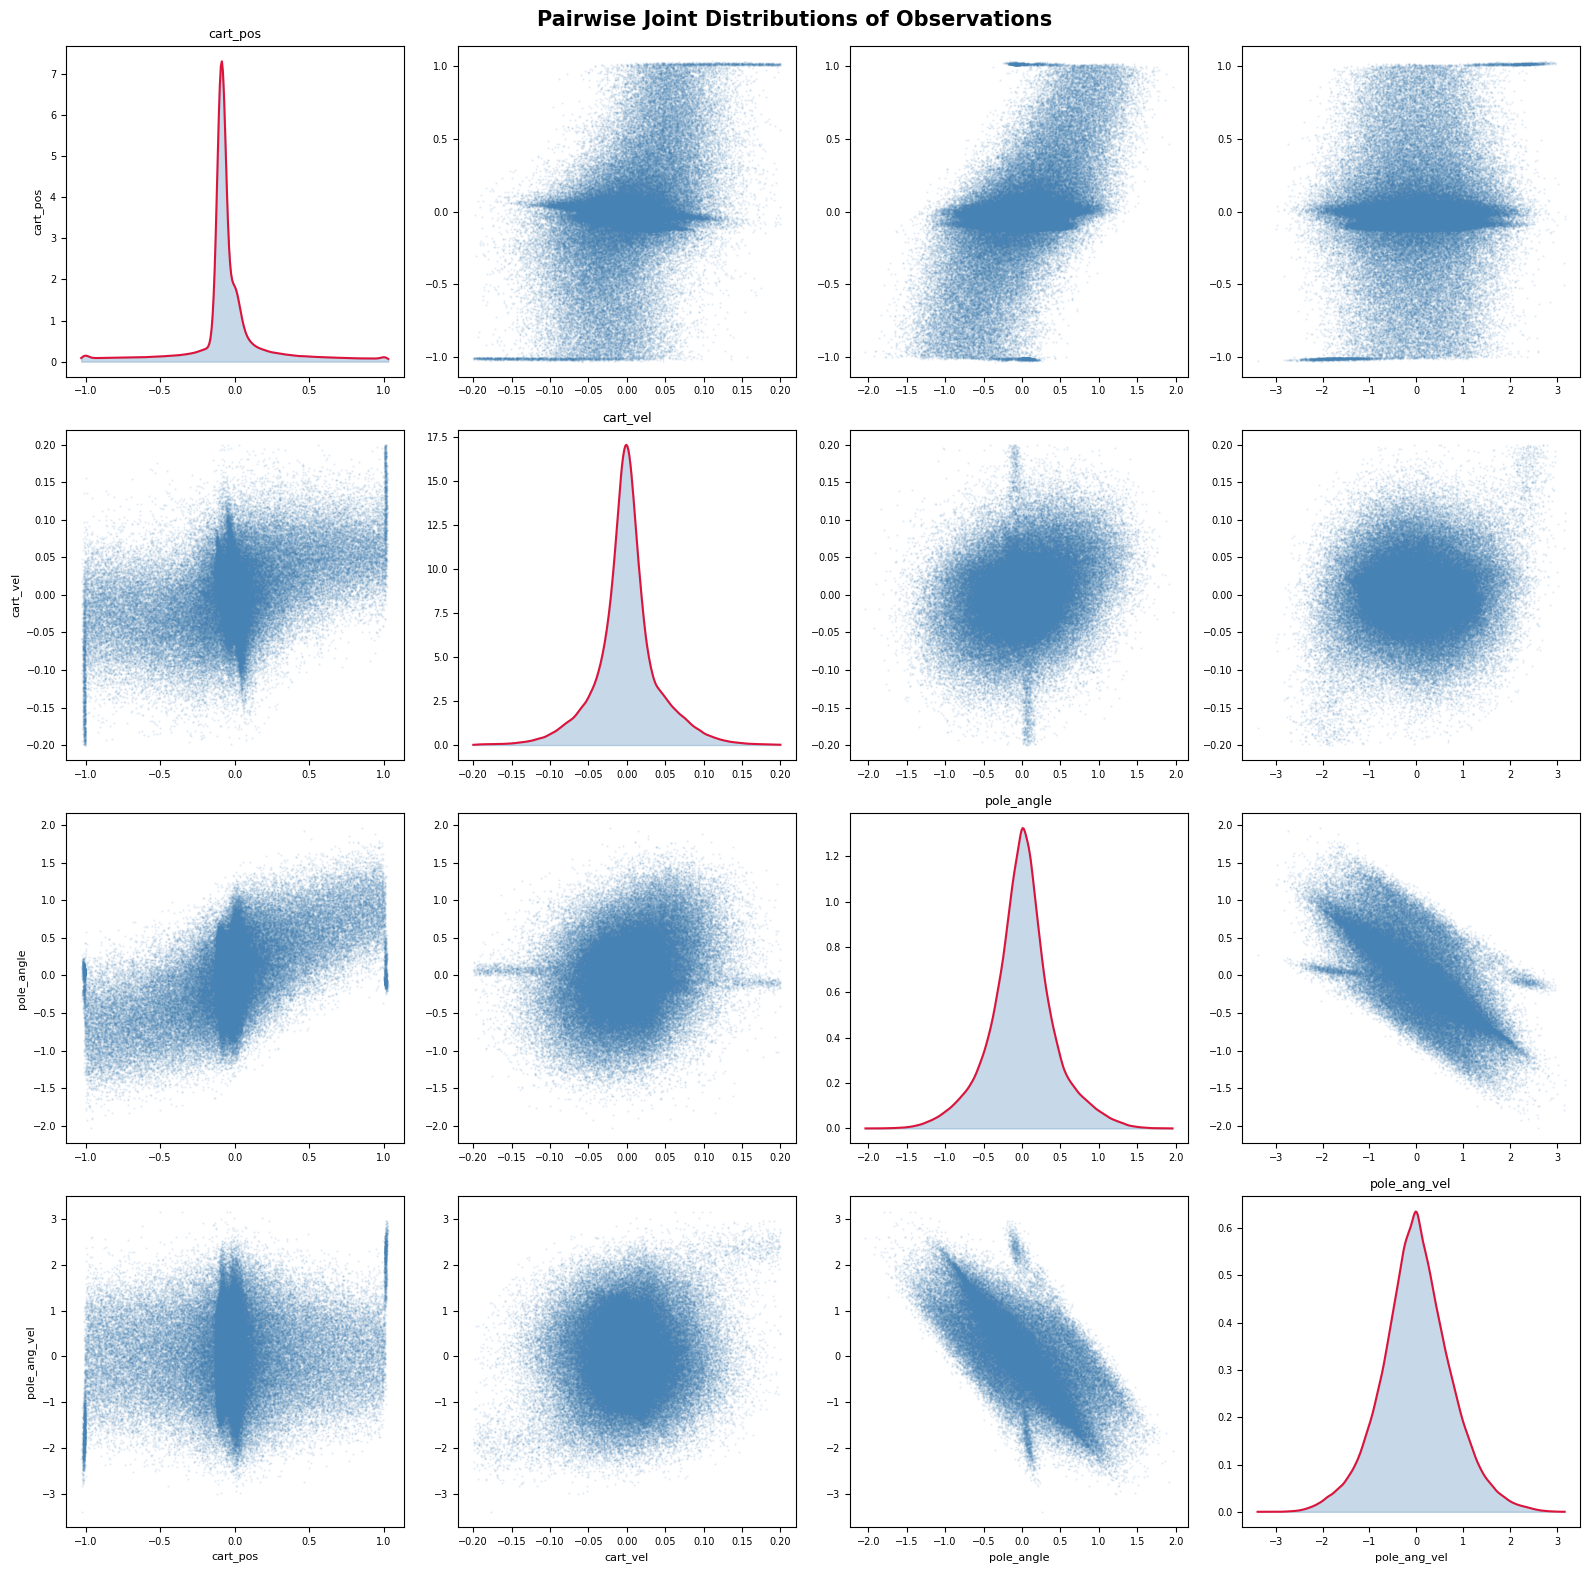

In [6]:
COL_NAMES = ["cart_pos", "cart_vel", "pole_angle", "pole_ang_vel"]

# --- Statistics ---
print(f"{'Column':<18} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'Median':>10} {'Skew':>10} {'Kurt':>10}")
print("-" * 100)
for i, name in enumerate(COL_NAMES):
    col = all_observations[:, i]
    print(f"{name:<18} {col.min():>10.4f} {col.max():>10.4f} {col.mean():>10.4f} "
          f"{col.std():>10.4f} {np.median(col):>10.4f} {skew(col):>10.4f} {kurtosis(col):>10.4f}")

# --- PDF Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(COL_NAMES, axes)):
    col = all_observations[:, i]
    kde = gaussian_kde(col)
    x = np.linspace(col.min(), col.max(), 500)
    ax.hist(col, bins=80, density=True, alpha=0.4, color="steelblue", label="Histogram")
    ax.plot(x, kde(x), color="crimson", linewidth=2, label="KDE")
    ax.set_title(f"PDF: {name}", fontsize=13)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Marginal PDFs of Observation Dimensions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Pairplot-style joint scatter with KDE marginals ---
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            col = all_observations[:, i]
            kde = gaussian_kde(col)
            x = np.linspace(col.min(), col.max(), 300)
            ax.plot(x, kde(x), color="crimson")
            ax.fill_between(x, kde(x), alpha=0.3, color="steelblue")
            ax.set_title(COL_NAMES[i], fontsize=9)
        else:
            ax.scatter(all_observations[:, j], all_observations[:, i],
                       s=0.5, alpha=0.1, color="steelblue")
        if i == 3:
            ax.set_xlabel(COL_NAMES[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(COL_NAMES[i], fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle("Pairwise Joint Distributions of Observations", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Statistics of Observations conditioned on Target State (Pole Angle close to 0)

Samples satisfying condition: 13719 / 199075 (6.89%)


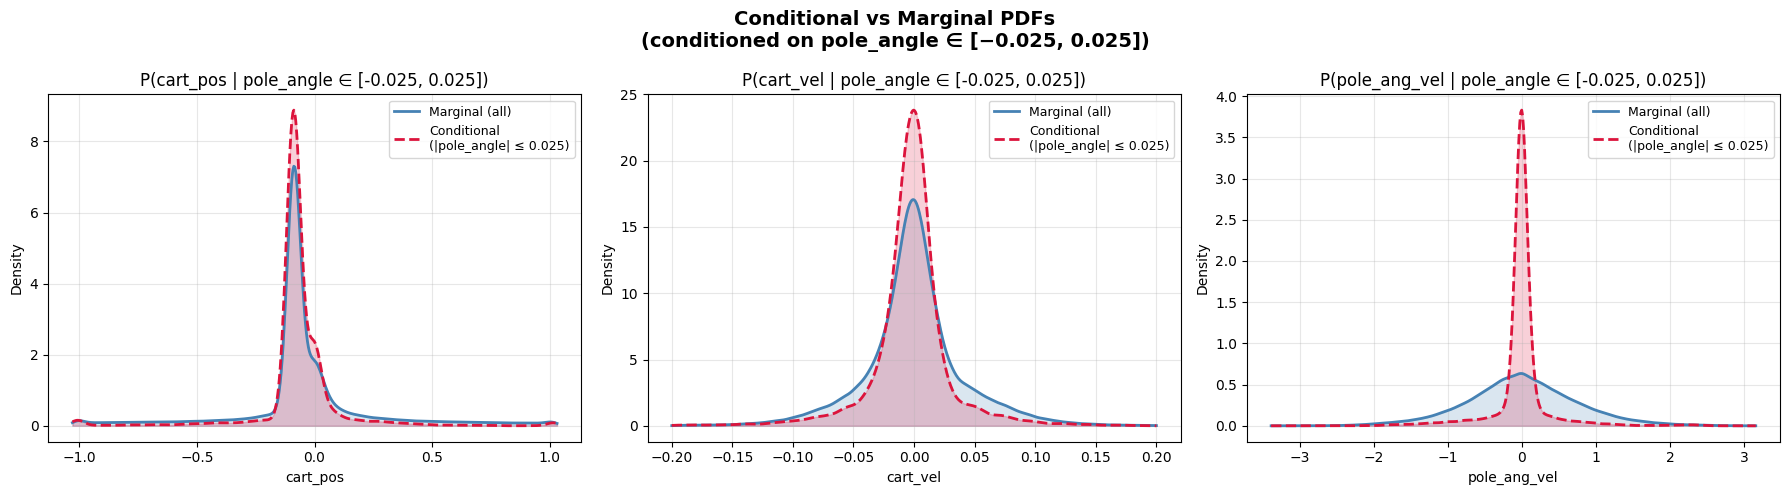

In [7]:
COL_NAMES_COND = ["cart_pos", "cart_vel", "pole_ang_vel"]
COL_INDICES = [0, 1, 3]
TOLERANCE = 0.025

# Condition: pole_angle (col 2) in [-TOLERANCE, +TOLERANCE]
mask = (all_observations[:, 2] >= -TOLERANCE) & (all_observations[:, 2] <= TOLERANCE)
obs_conditioned = all_observations[mask]
obs_unconditioned = all_observations

print(f"Samples satisfying condition: {mask.sum()} / {len(all_observations)} ({100*mask.mean():.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col_idx, name in zip(axes, COL_INDICES, COL_NAMES_COND):
    col_all = obs_unconditioned[:, col_idx]
    col_cond = obs_conditioned[:, col_idx]

    x_min = min(col_all.min(), col_cond.min())
    x_max = max(col_all.max(), col_cond.max())
    x = np.linspace(x_min, x_max, 500)

    kde_all = gaussian_kde(col_all)
    kde_cond = gaussian_kde(col_cond)

    ax.plot(x, kde_all(x), color="steelblue", linewidth=2, label="Marginal (all)")
    ax.fill_between(x, kde_all(x), alpha=0.2, color="steelblue")
    ax.plot(x, kde_cond(x), color="crimson", linewidth=2, linestyle="--",
            label=f"Conditional\n(|pole_angle| ≤ {TOLERANCE:g})")
    ax.fill_between(x, kde_cond(x), alpha=0.2, color="crimson")

    ax.set_title(f"P({name} | pole_angle ∈ [-{TOLERANCE:g}, {TOLERANCE:g}])", fontsize=12)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Conditional vs Marginal PDFs\n(conditioned on pole_angle ∈ [−{TOLERANCE:g}, {TOLERANCE:g}])",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Create 'instruction' vector indicating if observation maps to task completion (=1.0) or not (=0.0)

In [8]:
threshold = 0.025

instruction = (np.abs(all_observations[:, 2]) <= threshold).astype(np.float32).reshape(-1, 1)

print("instruction shape:", instruction.shape)
print("num ones:", int(instruction.sum()), "num zeros:", instruction.shape[0] - int(instruction.sum()))

instruction shape: (199075, 1)
num ones: 13719 num zeros: 185356


## Create critic SOM weights/prototypes

In [9]:
# prototype weights
W = np.random.uniform(-1.0, 1.0, size=(11, 11, 4))

# post-synaptic activations
M = np.zeros((11, 11))

In [10]:
def update_critsom(observation, W, M, instruction, lr, sigma):
    """
    Update critic SOM weights and post-synaptic map.

    Parameters
    ----------
    observation : np.ndarray, shape (1, 4) or (4,)
    W           : np.ndarray, shape (11, 11, 4)
    M           : np.ndarray, shape (11, 11)
    instruction  : scalar
    lr          : scalar
    sigma       : scalar

    Returns
    -------
    W, M, bmu : updated arrays and BMU index tuple
    """
    x = np.asarray(observation).reshape(-1)
    if x.shape[0] != W.shape[2]:
        raise ValueError(f"Observation dimension {x.shape[0]} does not match W.shape[2]={W.shape[2]}.")

    # 1) Forced BMU at center when instruction == 1.0
    if np.isclose(instruction, 1.0):
        bmu = (5, 5)

    # 2) Normal SOM BMU when instruction != 0
    else:
        dists = np.linalg.norm(W - x, axis=2)
        bmu = np.unravel_index(np.argmin(dists), dists.shape)


    # Gaussian neighborhood around BMU
    ii, jj = np.indices(M.shape)
    dist2 = (ii - bmu[0])**2 + (jj - bmu[1])**2
    h = np.exp(-dist2 / (2.0 * (float(sigma) ** 2)))

    # Store post-synaptic activation map
    M[:, :] = h

    # SOM weight update
    W[:, :, :] += float(lr) * h[:, :, None] * (x[None, None, :] - W)

    return W, M, bmu

## Iterate through each sample observation, updating CritSOM and generating diagnostics along the way

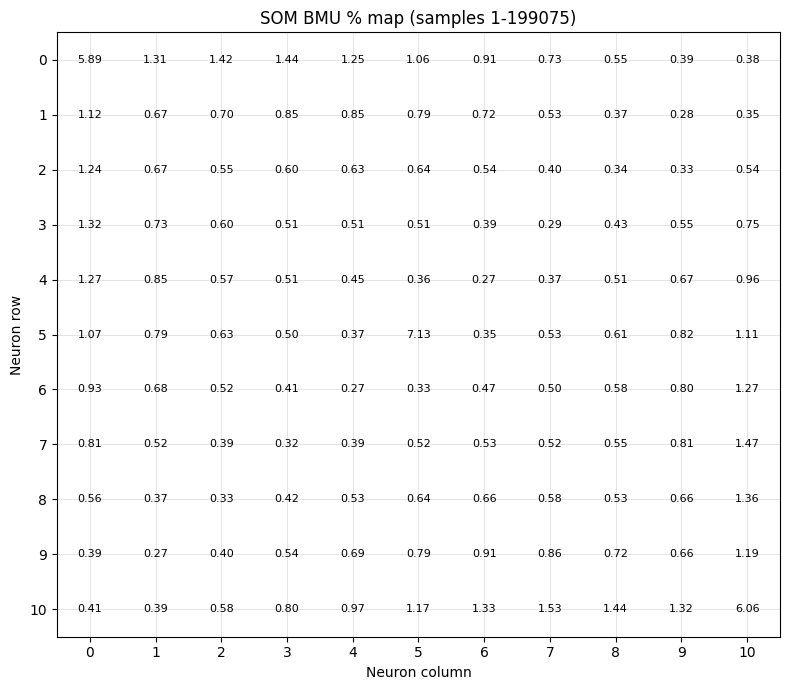

In [26]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

lr = 0.3
sigma = 2.0

chunk_size = 10_000
chunk_counts = np.zeros((11, 11), dtype=np.int32)
chunk_total = 0
num_episodes = 1

base_observations = all_observations
base_instruction = instruction

# Treat one full pass over all rows as one episode, then stack episodes
all_observations = np.tile(base_observations, (num_episodes, 1))
instruction = np.tile(base_instruction, (num_episodes, 1))

# Force the existing plotting block to run only once at the very end
chunk_size = all_observations.shape[0]
for idx, (obs_row, inst_row) in enumerate(zip(all_observations, instruction), start=1):
    inst_scalar = float(inst_row[0])
    W, M, bmu = update_critsom(obs_row, W, M, inst_scalar, lr, sigma)

    # Render numeric "heatmap" once at the end (no color encoding)
    if idx == all_observations.shape[0]:
        projected_counts = chunk_counts.copy()
        if bmu is not None:
            projected_counts[bmu] += 1

        # Animate first 50 post-synaptic heatmaps at 5 FPS

        n_frames = min(50, all_observations.shape[0])
        W_anim = W.copy()
        M_anim = np.zeros_like(M)
        frames = []

        for k in range(n_frames):
            obs_k = all_observations[k]
            inst_k = float(instruction[k, 0])
            _, M_anim, _ = update_critsom(obs_k, W_anim, M_anim, inst_k, lr=0.0, sigma=sigma)
            frames.append(M_anim.copy())

        fig_anim, ax_anim = plt.subplots(figsize=(6, 5))
        im_anim = ax_anim.imshow(frames[0], cmap="hot", origin="upper", vmin=0.0, vmax=1.0)
        ax_anim.set_xlabel("Neuron column")
        ax_anim.set_ylabel("Neuron row")
        plt.colorbar(im_anim, ax=ax_anim, label="Activation")

        def _update(frame_idx):
            im_anim.set_data(frames[frame_idx])
            ax_anim.set_title(f"Post-synaptic heatmap (frame {frame_idx + 1}/{n_frames})")
            return (im_anim,)

        anim = FuncAnimation(
            fig_anim,
            _update,
            frames=n_frames,
            interval=200,  # 5 FPS
            blit=True,
            repeat=False,
        )

        display(HTML(anim.to_jshtml()))
        plt.close(fig_anim)
        projected_total = chunk_total + 1
        percent_map = (projected_counts / projected_total) * 100.0

        fig, ax = plt.subplots(figsize=(8, 7))
        ax.set_title(f"SOM BMU % map (samples 1-{idx})")
        ax.set_xlabel("Neuron column")
        ax.set_ylabel("Neuron row")
        ax.set_xlim(-0.5, 10.5)
        ax.set_ylim(10.5, -0.5)
        ax.set_xticks(range(11))
        ax.set_yticks(range(11))
        ax.grid(True, which="both", linewidth=0.6, alpha=0.4)

        for r in range(11):
            for c in range(11):
                ax.text(c, r, f"{percent_map[r, c]:.2f}",
                        ha="center", va="center", fontsize=8)

        plt.tight_layout()
        plt.show()

        # Prevent the original color-imshow block from running
        chunk_size = all_observations.shape[0] + 1

    if bmu is not None:
        chunk_counts[bmu] += 1
    chunk_total += 1

    if idx % chunk_size == 0:
        percent_map = (chunk_counts / chunk_total) * 100.0  # denominator: previous 10,000 observations

        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(percent_map, cmap="viridis", origin="upper")
        ax.set_title(f"SOM BMU % map (samples {idx-chunk_size+1}-{idx})")
        ax.set_xlabel("Neuron column")
        ax.set_ylabel("Neuron row")
        plt.colorbar(im, ax=ax, label="% of observations")
        plt.tight_layout()
        plt.show()

        chunk_counts.fill(0)
        chunk_total = 0